# AIoT Project

In [2]:
import os

# basic data engineering
import pandas as pd
import numpy as np
import scipy

# plotting
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.feature_selection import SelectKBest, f_classif



# db
import pymongo
from bson import ObjectId

# configs & other
import yaml
from tqdm.notebook import tqdm_notebook
from datetime import datetime
from time import time

from psynlig import pca_explained_variance_bar

# utils processing
from utils import sliding_window_pd
from utils import apply_filter
from utils import filter_instances
from utils import flatten_instances_df
from utils import df_rebase
from utils import rename_df_column_values

# utils visualization
from utils_visual import plot_instance_time_domain
from utils_visual import plot_instance_3d
from utils_visual import plot_np_instance
from utils_visual import plot_heatmap
from utils_visual import plot_scatter_pca
from utils_visual import plot_bar
from utils_visual import plot_distribution_analysis

%load_ext autoreload
%autoreload 2

Start time of execution

In [3]:
time_start = time()

## Load configuration

In [4]:
config_path = os.path.join(os.getcwd(), "config.yml")

with open(config_path) as file:
    config = yaml.load(file, Loader=yaml.FullLoader)

In [5]:
axes = config['rename']
print(axes)

['acc_x', 'acc_y', 'acc_z', 'gyr_x', 'gyr_y', 'gyr_z']


In [6]:
client = pymongo.MongoClient(config["client"])

In [7]:
db = client[config["db"]]
coll = db[config["col"]]

In [8]:
found_keys = coll.distinct("_id")
print(f'Found {len(found_keys)} keys in the collection')

Found 75 keys in the collection


## Load data

In [9]:
# scroll up data
# results = list(coll.find({"gesture_id": "scroll-up-index"}, {"data": True, "gesture_id": True}))
results = list(coll.find( {},
    # {'user': {'$ne': '02'}}, 
    {"data": 1, "gesture_id": 1, "user": 1, "_id": 0}
))
print(f'Found {len(results)} keys in the collection')

Found 75 keys in the collection


In [10]:
print(results[0].keys())

dict_keys(['data', 'gesture_id', 'user'])


In [11]:
def chop_edges_and_concat(results):
    all_chunks = pd.DataFrame(results)
    # print(len(all_chunks))

    ids = all_chunks['gesture_id'].unique().tolist()
    # print(ids)

    gestures = {}
    for id in ids:
        gesture_chunks = all_chunks[all_chunks['gesture_id'] == id]
        print(gesture_chunks.columns)
        current_data = gesture_chunks[['user', 'data']]
        
        chunks = []
        for chunk in current_data.itertuples():
            # print(type(chunk))
            # print(chunk)
            df = pd.DataFrame(chunk.data)
            df.drop(df.tail(200).index, inplace=True)
            df.drop(df.head(200).index, inplace=True)
            df['user'] = chunk.user
            chunks.append((id, df))

        joined_gesture = pd.concat([df for _, df in chunks], ignore_index=True)
        gestures[id] = joined_gesture

        # print(len(chunks[0][1]))
        # print(chunks[0][1].head())

        # print(len(joined_gesture))
        # print(joined_gesture.head())
    return gestures
    
    
# gestures = chop_edges_and_concat(results)
# print(len(gestures))
# print(gestures['scroll-up-index'])


In [12]:
# print(type(gestures))
# print(len(gestures))
# print(gestures['scroll-down-index']) 

## Explore the nature of the data

In [13]:
# sampling_rate = 100
# durations = []
# for gesture_id, df in gestures.items():
#     total_samples = len(df)
#     duration_seconds = total_samples / sampling_rate
#     durations.append({'Gesture': gesture_id, 'Duration (s)':
#         duration_seconds})

# duration_df = pd.DataFrame(durations)
# print(duration_df)
   
# plot_bar(duration_df, title='Total Collected Time-Length per Gesture Class')

## Data Processing

We Filter for Glitches/Outliers

In [14]:
def clean_sensor_outliers(df, window_size=50, threshold=3.0, axes = ['acc_x', 'acc_y', 'acc_z', 'gyr_x', 'gyr_y', 'gyr_z']):
    """
    Cleans extreme hardware spikes using a Rolling Z-Score and Linear Interpolation.
    Assumes 100Hz data (window_size=50 is 0.5 seconds).
    """
    # Create a copy so we don't accidentally overwrite your raw data
    df_clean = df.copy()
    
    # Define your 6 sensor columns from the MetaMotionR IMU
    sensor_columns = axes
    
    for col in sensor_columns:
        # 1. Calculate Rolling Mean and Standard Deviation
        # 'center=True' ensures the window looks at points both before and after the current row
        rolling_mean = df_clean[col].rolling(window=window_size, center=True).mean()
        rolling_std = df_clean[col].rolling(window=window_size, center=True).std()
        
        global_mean = df_clean[col].mean()
        global_std = df_clean[col].std()
        
        # 2. Calculate the Rolling Z-Score
        rolling_z_scores = np.abs((df_clean[col] - rolling_mean) / rolling_std)
        global_scores = np.abs((df_clean[col] - global_mean) / global_std)
        
        # 3. Find how many outliers we are catching (Great for your EDA Report!)
        outlier_count = (rolling_z_scores > threshold).sum()
        print(f"Cleaned {outlier_count} glitches in {col}")
        
        # 4. Replace those specific outliers with NaN
        df_clean.loc[rolling_z_scores > threshold, col] = np.nan
        df_clean.loc[global_scores > 2.0, col] = np.nan
        
        # 5. Apply Linear Interpolation to smoothly connect the gaps
        # limit_direction='both' ensures it fixes glitches even if they happen on the very first or last row
        df_clean[col] = df_clean[col].interpolate(method='linear', limit_direction='both')
        
    return df_clean


def purge_outliers_all_gestures(gestures, axes=['acc_x', 'acc_y', 'acc_z', 'gyr_x', 'gyr_y', 'gyr_z'], window_size=50, threshold=3.0):
    cleaned_gestures = {}
    for gesture_id, gesture_df in gestures.items():
        print(f'Cleaning gesture: {gesture_id}')
        gesture_cleaned = clean_sensor_outliers(gesture_df, window_size, threshold, axes)
        cleaned_gestures[gesture_id] = gesture_cleaned
    return cleaned_gestures

# cleaned_gestures = purge_outliers_all_gestures(gestures, window_size=50, threshold=2.0)

# Check the first few rows to ensure everything looks correct
# display(cleaned_gestures['scroll-up-index'].head())
# plot_instance_time_domain(gestures['scroll-up-index'])
# plot_instance_time_domain(gestures['scroll-up-index'])
# plot_instance_time_domain(cleaned_gestures['scroll-up-index'])
# plot_instance_time_domain(cleaned_gestures['scroll-up-index'])


In [15]:
# # strucure of cleaned_gestures:
# print(type(cleaned_gestures))
# print(cleaned_gestures.keys())
# print(len(cleaned_gestures))
# print(len(cleaned_gestures['scroll-down-index']))
# print(cleaned_gestures['scroll-down-index'])

## Sensor-type grouped scaling

In [16]:

def scale_gestures(gestures_train, gestures_val):
    std_scaler = StandardScaler()
    robust_scaler = RobustScaler()

    all_train_data = pd.concat(gestures_train.values())
    std_scaler.fit(all_train_data[['acc_x', 'acc_y', 'acc_z']])
    robust_scaler.fit(all_train_data[['gyr_x', 'gyr_y', 'gyr_z']])

    for id in gestures_train:
        gestures_train[id][['acc_x', 'acc_y','acc_z']] = std_scaler.transform(gestures_train[id][['acc_x', 'acc_y', 'acc_z']])
        gestures_train[id][['gyr_x', 'gyr_y', 'gyr_z']] = robust_scaler.transform(gestures_train[id][['gyr_x', 'gyr_y', 'gyr_z']])
        
    for id in gestures_val:
        gestures_val[id][['acc_x', 'acc_y', 'acc_z']] = std_scaler.transform(gestures_val[id][['acc_x', 'acc_y', 'acc_z']])
        gestures_val[id][['gyr_x', 'gyr_y', 'gyr_z']] = robust_scaler.transform(gestures_val[id][['gyr_x', 'gyr_y', 'gyr_z']])
    
# scale_gestures(gestures_train, gestures_val)
    

## We use sliding windowing to create our samples

In [17]:
# --- REPLACEMENT FOR CELL 18 ---
import scipy.stats as stats
import pandas as pd
import numpy as np

def window_and_filter_gestures(cleaned_gestures, ws=200, overlap=50, order=5, wn=0.3, filter_type='lowpass'):
    clips_arr = []
    featurized_gestures = {}
    
    for id, data in cleaned_gestures.items():
        filtered_data = data.drop(columns='user').apply(apply_filter, args=(order, wn, filter_type))

        clips = sliding_window_pd(filtered_data, ws=ws, overlap=overlap, print_stats=False)
        total_clips = len(clips)
        clips_arr.append({'Gesture': id, 'Total Clips': total_clips})
        
        # 3. Feature Extraction 
        extracted_windows = []
        for window in clips:
            if not isinstance(window, pd.DataFrame):
                window = pd.DataFrame(window, columns=['acc_x', 'acc_y', 'acc_z', 'gyr_x', 'gyr_y', 'gyr_z'])
            
            window_features = {}
            for col in window.columns:
                vals = window[col].values

                # Time-Domain
                window_features[f'{col}_mean'] = np.mean(vals)
                window_features[f'{col}_std'] = np.std(vals)
                window_features[f'{col}_rms'] = np.sqrt(np.mean(vals**2))
                window_features[f'{col}_skew'] = stats.skew(vals)
                window_features[f'{col}_kurtosis'] = stats.kurtosis(vals)
                window_features[f'{col}_iqr'] = stats.iqr(vals)
                zero_crosses = np.where(np.diff(np.sign(vals - np.mean(vals))))[0]
                window_features[f'{col}_zcr'] = len(zero_crosses)
                
                # Frequency-Domain
                fs = 100 
                fft_vals = np.fft.rfft(vals)
                fft_mag = np.abs(fft_vals) / len(vals)
                fft_freqs = np.fft.rfftfreq(len(vals), d=1/fs)

                window_features[f'{col}_spectral_energy'] = np.sum(fft_mag**2)
                
                dom_freq_idx = np.argmax(fft_mag)
                window_features[f'{col}_dom_freq'] = fft_freqs[dom_freq_idx]
                
                sum_mag = np.sum(fft_mag)
                window_features[f'{col}_mean_freq'] = (np.sum(fft_freqs * fft_mag) / sum_mag) if sum_mag > 0 else 0.0
                
                if sum_mag > 0:
                    pmf = fft_mag / sum_mag
                    pmf = pmf[pmf > 0]
                    window_features[f'{col}_spectral_entropy'] = stats.entropy(pmf)
                else:
                    window_features[f'{col}_spectral_entropy'] = 0.0

            # Cross-Channel
            ax, ay, az = window['acc_x'].values, window['acc_y'].values, window['acc_z'].values
            gx, gy, gz = window['gyr_x'].values, window['gyr_y'].values, window['gyr_z'].values
            N = len(ax)
            
            window_features['acc_vm_mean'] = np.mean(np.sqrt(ax**2 + ay**2 + az**2))
            window_features['gyr_vm_mean'] = np.mean(np.sqrt(gx**2 + gy**2 + gz**2))
            window_features['acc_sma'] = np.sum(np.abs(ax) + np.abs(ay) + np.abs(az)) / N
            window_features['gyr_sma'] = np.sum(np.abs(gx) + np.abs(gy) + np.abs(gz)) / N
            
            window_features['acc_corr_xy'] = np.nan_to_num(np.corrcoef(ax, ay)[0, 1])
            window_features['acc_corr_xz'] = np.nan_to_num(np.corrcoef(ax, az)[0, 1])
            window_features['acc_corr_yz'] = np.nan_to_num(np.corrcoef(ay, az)[0, 1])
            window_features['gyr_corr_xy'] = np.nan_to_num(np.corrcoef(gx, gy)[0, 1])
            window_features['gyr_corr_xz'] = np.nan_to_num(np.corrcoef(gx, gz)[0, 1])
            window_features['gyr_corr_yz'] = np.nan_to_num(np.corrcoef(gy, gz)[0, 1])
                
            extracted_windows.append(window_features)
            
        # Store features
        df_features = pd.DataFrame(extracted_windows)
        
        # Clean Inf and NaN before returning
        df_features = df_features.replace([np.inf, -np.inf], np.nan)
        df_features = df_features.fillna(0) # Fill NaNs to prevent downstream errors
        
        featurized_gestures[id] = df_features

    return featurized_gestures, clips_arr

In [18]:
def drop_highly_correlated_features(X_train, X_val, threshold=0.95):
    """
    Identifies and drops highly correlated features using the Spearman method.
    Fits on the training data only to prevent data leakage.
    """
    # 1. Calculate correlation matrix on training data
    corr_matrix = X_train.corr(method='spearman').abs()
    
    # 2. Select the upper triangle of the correlation matrix
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    
    # 3. Find features with a correlation strictly greater than the threshold
    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]
    
    # 4. Drop those features from both training and validation sets
    X_train_clean = X_train.drop(columns=to_drop)
    X_val_clean = X_val.drop(columns=to_drop)
    
    return X_train_clean, X_val_clean, to_drop

## Classifier - Statistical Learning

### unpack dict data for scikitlearn model

In [19]:
def prepare_xy(gesture_dict):
    # Combine all DataFrames in the dictionary into one
    X_combined = pd.concat(gesture_dict.values(), ignore_index=True)
    
    # Create the label array (y)
    y = []
    for gesture_name, df in gesture_dict.items():
        y.extend([gesture_name] * len(df))
    
    return X_combined, np.array(y)

# X_train, y_train = prepare_xy(train_clips_flattened)
# X_val, y_val = prepare_xy(val_clips_flattened)

# print("X_train shape: ", X_train.shape)
# print("Y_train shape: ", y_train.shape)

In [27]:
def process_fold(gestures_train, gestures_val):
    # 1. Scaling 
    scale_gestures(gestures_train, gestures_val)
    
    # 2. Windowing and extraction
    train_features_dict, _ = window_and_filter_gestures(gestures_train, ws=200, overlap=50, order=5, wn=0.4)
    val_features_dict, _ = window_and_filter_gestures(gestures_val, ws=200, overlap=50, order=5, wn=0.4)
    
    X_train, y_train = prepare_xy(train_features_dict)
    X_val, y_val = prepare_xy(val_features_dict)
    
    # 3. Redundancy Check (Correlation Filter)
    X_train_clean, X_val_clean, dropped_cols = drop_highly_correlated_features(X_train, X_val, threshold=0.90)
    
    # 4. Feature Selection (Top 15)
    selector = SelectKBest(score_func=f_classif, k=15)
    X_train_final = selector.fit_transform(X_train_clean, y_train)
    X_val_final = selector.transform(X_val_clean)
    
    # --- MULTI-MODEL CLASSIFICATION ---
    models = {
        "Random Forest": RandomForestClassifier(n_estimators=50, min_samples_split=2, min_samples_leaf=1, bootstrap=False, max_depth=None, random_state=42),
        # "SVM (RBF Kernel)": SVC(kernel='rbf', random_state=42),
        # "Logistic Regression": LogisticRegression(max_iter=2000, random_state=42)
    }
    
    fold_predictions = {}
    
    for model_name, model in models.items():
        # Train the model
        model.fit(X_train_final, y_train)
        # Store its predictions for this fold
        fold_predictions[model_name] = model.predict(X_val_final)
    
    # Return true labels, and a dictionary of predictions
    return y_val, fold_predictions

## Standard Cross Val

In [28]:
from sklearn.model_selection import KFold

n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=False)

print(axes)

# default cleaning
gestures = chop_edges_and_concat(results)
cleaned_gestures = purge_outliers_all_gestures(gestures)

# --- NEW: Initialize tracking for multiple models ---
all_y_true = []
all_y_pred = {
    "Random Forest": [],
    # "SVM (RBF Kernel)": [],
    # "Logistic Regression": []
}

for fold in range(n_splits):
    print(f"\n--- Running Fold: {fold + 1}/{n_splits} ---")
    
    fold_train = {}
    fold_val = {}
    
    # Iterate through each gesture to split the data
    for gid, df in cleaned_gestures.items():
        train_dfs = []
        val_dfs = []
        
        # Split each user's continuous data 80/20 chronologically
        unique_users = df['user'].unique()
        for user in unique_users:
            user_df = df[df['user'] == user]
            
            # Use kf.split to get the indices for the current fold
            splits = list(kf.split(user_df))
            train_idx, val_idx = splits[fold]
            
            # Grab the 80% train and 20% val indices
            train_dfs.append(user_df.iloc[train_idx])
            val_dfs.append(user_df.iloc[val_idx])
            
        # Re-assemble and explicitly copy to prevent SettingWithCopyWarnings
        fold_train[gid] = pd.concat(train_dfs).copy()
        fold_val[gid] = pd.concat(val_dfs).copy()
        
    # --- NEW: Process the fold using our multi-model function ---
    y_val_true, fold_preds = process_fold(fold_train, fold_val)
    
    # Store true labels
    all_y_true.extend(y_val_true)
    
    # Store predictions for each model
    for model_name in all_y_pred.keys():
        all_y_pred[model_name].extend(fold_preds[model_name])
        
print("\nK-Fold Cross-Validation Complete!")

[<Axes: title={'center': 'Random Forest'}, xlabel='Predicted label', ylabel='True label'>
 <Axes: title={'center': 'SVM (RBF Kernel)'}, xlabel='Predicted label', ylabel='True label'>
 <Axes: title={'center': 'Logistic Regression'}, xlabel='Predicted label', ylabel='True label'>]
Index(['data', 'gesture_id', 'user'], dtype='str')
Index(['data', 'gesture_id', 'user'], dtype='str')
Index(['data', 'gesture_id', 'user'], dtype='str')
Index(['data', 'gesture_id', 'user'], dtype='str')
Index(['data', 'gesture_id', 'user'], dtype='str')
Cleaning gesture: scroll-down-index
Cleaned 186 glitches in acc_x
Cleaned 52 glitches in acc_y
Cleaned 68 glitches in acc_z
Cleaned 8 glitches in gyr_x
Cleaned 40 glitches in gyr_y
Cleaned 12 glitches in gyr_z
Cleaning gesture: scroll-up-index
Cleaned 124 glitches in acc_x
Cleaned 36 glitches in acc_y
Cleaned 43 glitches in acc_z
Cleaned 7 glitches in gyr_x
Cleaned 62 glitches in gyr_y
Cleaned 7 glitches in gyr_z
Cleaning gesture: texting-single
Cleaned 623 gli

🏆 K-FOLD CROSS-VALIDATION RESULTS (Top 15 Features)

---> RANDOM FOREST <---
                   precision    recall  f1-score   support

scroll-down-index       0.70      0.84      0.76      1905
  scroll-up-index       0.88      0.79      0.83      1920
 swipe-left-index       0.85      0.89      0.87      1925
swipe-right-index       0.72      0.62      0.67      1975
   texting-single       0.99      0.99      0.99      1900

         accuracy                           0.82      9625
        macro avg       0.83      0.83      0.82      9625
     weighted avg       0.83      0.82      0.82      9625



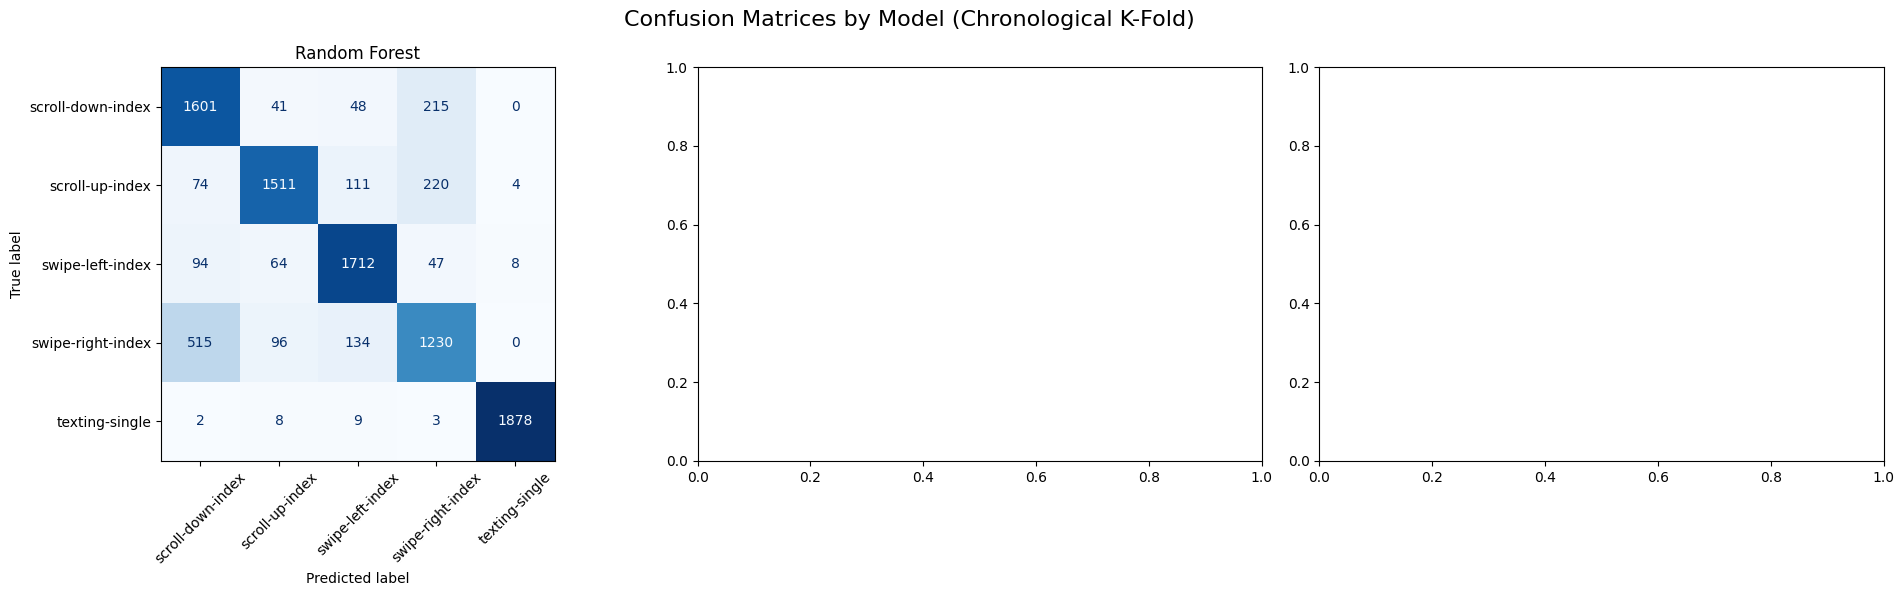

In [29]:
# --- EVALUATION AND VISUALIZATION ---
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Print Text Reports
print("="*60)
print("🏆 K-FOLD CROSS-VALIDATION RESULTS (Top 15 Features)")
print("="*60)

for model_name, y_pred in all_y_pred.items():
    print(f"\n---> {model_name.upper()} <---")
    # zero_division=0 suppresses warnings if a model totally fails on a class
    print(classification_report(all_y_true, y_pred, zero_division=0))

# 2. Plot Side-by-Side Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Confusion Matrices by Model (Chronological K-Fold)', fontsize=16)

for ax, (model_name, y_pred) in zip(axes, all_y_pred.items()):
    ConfusionMatrixDisplay.from_predictions(
        all_y_true, 
        y_pred, 
        ax=ax, 
        cmap='Blues',
        colorbar=False,
        xticks_rotation=45
    )
    ax.set_title(model_name)

plt.tight_layout()
plt.show()

## Leave One Subject Out Cross Validation LOSO-CV

In [ ]:
unique_users = ['01', '02', '03']

# default cleaning
gestures = chop_edges_and_concat(results)

# MUST STAY OFF: purge_outliers_all_gestures(gestures)

# Initialize structures to hold results for all models
all_y_true = []
all_y_pred = {
    "Random Forest": [],
    "SVM (RBF Kernel)": [],
    "Logistic Regression": []
}

for holdout_user in unique_users:
    print(f"--- Running Fold: User {holdout_user} is Validation ---")
    
    # 1. Split by user
    fold_train = {gid: df[df['user'] != holdout_user].copy() for gid, df in gestures.items()}
    fold_val = {gid: df[df['user'] == holdout_user].copy() for gid, df in gestures.items()}
    
    # 2. Call our new multi-model process_fold
    y_val_true, fold_preds = process_fold(fold_train, fold_val)
    
    # 3. Store true labels
    all_y_true.extend(y_val_true)
    
    # 4. Store predictions for each model
    for model_name in all_y_pred.keys():
        all_y_pred[model_name].extend(fold_preds[model_name])
        
print("Cross-Validation Complete!")

Index(['data', 'gesture_id', 'user'], dtype='str')
Index(['data', 'gesture_id', 'user'], dtype='str')
Index(['data', 'gesture_id', 'user'], dtype='str')
Index(['data', 'gesture_id', 'user'], dtype='str')
Index(['data', 'gesture_id', 'user'], dtype='str')
--- Running Fold: User 01 is Validation ---
Number of filtered instances in the list: 1284
Number of filtered instances in the list: 1160
Number of filtered instances in the list: 1284
Number of filtered instances in the list: 1351
Number of filtered instances in the list: 1281
Number of filtered instances in the list: 630
Number of filtered instances in the list: 668
Number of filtered instances in the list: 627
Number of filtered instances in the list: 635
Number of filtered instances in the list: 655
--- Running Fold: User 02 is Validation ---
Number of filtered instances in the list: 1291
Number of filtered instances in the list: 1284
Number of filtered instances in the list: 1211
Number of filtered instances in the list: 1237
Numb

## loso results

In [ ]:
# --- EVALUATION AND VISUALIZATION ---
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Print Text Reports
print("="*50)
print("🏆 LOSO CROSS-VALIDATION RESULTS (Top 15 Features)")
print("="*50)

for model_name, y_pred in all_y_pred.items():
    print(f"\n---> {model_name.upper()} <---")
    # We use zero_division=0 to suppress warnings if a model fails completely on a class
    print(classification_report(all_y_true, y_pred, zero_division=0))

# 2. Plot Side-by-Side Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Confusion Matrices by Model', fontsize=16)

for ax, (model_name, y_pred) in zip(axes, all_y_pred.items()):
    ConfusionMatrixDisplay.from_predictions(
        all_y_true, 
        y_pred, 
        ax=ax, 
        cmap='Blues',
        colorbar=False,
        xticks_rotation=45
    )
    ax.set_title(model_name)

plt.tight_layout()
plt.show()

## K FOLD RESULTS

### Evaluate classifiers

### Apply optimization with Grid Search and/or Cross-validation

In [23]:
# --- 1. PREPARE FULL DATASET FOR TUNING ---
# We will use the full cleaned_gestures dictionary and run our extraction once
from sklearn.feature_selection import SelectKBest, f_classif

# Extract features
full_features_dict, _ = window_and_filter_gestures(cleaned_gestures, ws=200, overlap=50, order=5, wn=0.4)
X_full, y_full = prepare_xy(full_features_dict)

# Drop redundant features (>0.95 correlation)
corr_matrix = X_full.corr(method='spearman').abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]
X_full_clean = X_full.drop(columns=to_drop)

# Select Top 15 (Optional, but highly recommended for AIoT)
selector = SelectKBest(score_func=f_classif, k=15)
X_full_final = selector.fit_transform(X_full_clean, y_full)

print(f"Data ready for tuning! Shape: {X_full_final.shape}")

Data ready for tuning! Shape: (9695, 15)


In [24]:
# --- 2. HYPERPARAMETER TUNING (RANDOMIZED SEARCH) ---
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
import numpy as np

# Define the grid of parameters to test
# Notice we are testing very small forests (10, 25, 50 trees) for AIoT efficiency!
param_dist = {
    'n_estimators': [10, 25, 50, 75, 100, 150],
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

# Initialize a base model
rf_base = RandomForestClassifier(random_state=42)

# Set up the Random Search
# n_iter=50 means it will randomly test 50 different combinations from the grid above
# cv=5 means it will use 5-fold cross-validation internally to score them
random_search = RandomizedSearchCV(
    estimator=rf_base, 
    param_distributions=param_dist, 
    n_iter=50, 
    cv=5, 
    verbose=2, 
    random_state=42, 
    n_jobs=-1  # Uses all available CPU cores to speed it up!
)

# Fit the search (This might take a few minutes!)
print("Starting Random Search...")
random_search.fit(X_full_final, y_full)

print("\n"+"="*50)
print("🏆 BEST PARAMETERS FOUND:")
print("="*50)
print(random_search.best_params_)
print(f"Best Internal CV Accuracy: {random_search.best_score_ * 100:.2f}%")

Starting Random Search...
Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV] END bootstrap=True, max_depth=5, min_samples_leaf=2, min_samples_split=2, n_estimators=25; total time=   0.2s
[CV] END bootstrap=True, max_depth=5, min_samples_leaf=2, min_samples_split=2, n_estimators=25; total time=   0.1s
[CV] END bootstrap=True, max_depth=5, min_samples_leaf=2, min_samples_split=2, n_estimators=25; total time=   0.1s
[CV] END bootstrap=True, max_depth=5, min_samples_leaf=2, min_samples_split=2, n_estimators=25; total time=   0.1s
[CV] END bootstrap=True, max_depth=5, min_samples_leaf=2, min_samples_split=2, n_estimators=25; total time=   0.2s
[CV] END bootstrap=True, max_depth=20, min_samples_leaf=1, min_samples_split=10, n_estimators=25; total time=   0.3s
[CV] END bootstrap=True, max_depth=20, min_samples_leaf=1, min_samples_split=10, n_estimators=25; total time=   0.3s
[CV] END bootstrap=True, max_depth=20, min_samples_leaf=1, min_samples_split=10, n_estimators=25; total

### Evaluate optimized classifier

🏆 FINAL OPTIMIZED RANDOM FOREST RESULTS
                   precision    recall  f1-score   support

scroll-down-index       1.00      1.00      1.00      1918
  scroll-up-index       1.00      1.00      1.00      1933
 swipe-left-index       1.00      1.00      1.00      1940
swipe-right-index       1.00      1.00      1.00      1990
   texting-single       1.00      1.00      1.00      1914

         accuracy                           1.00      9695
        macro avg       1.00      1.00      1.00      9695
     weighted avg       1.00      1.00      1.00      9695



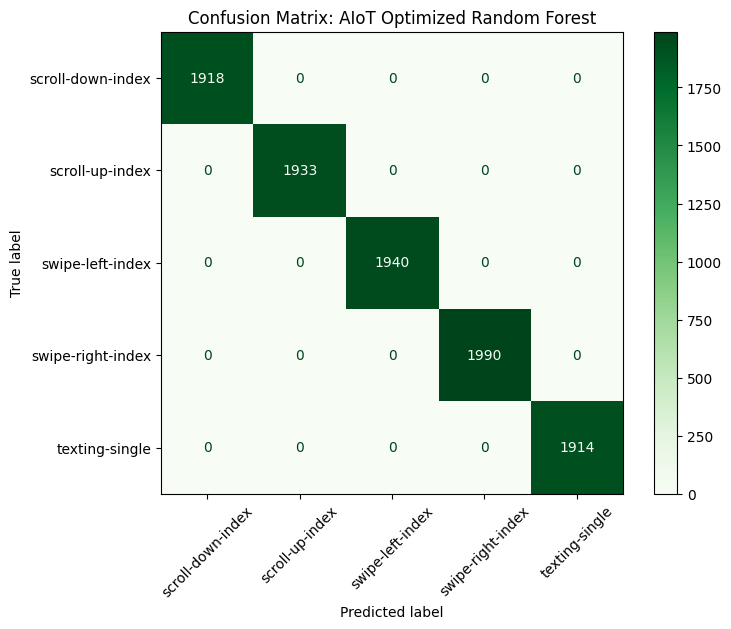

In [25]:
# --- EVALUATE OPTIMIZED CLASSIFIER ---
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Take the best model directly from our Random Search
best_rf_model = random_search.best_estimator_

# (Optional: If you want to see how it performs on the exact same full set, 
# though normally you'd evaluate on a completely hidden test set if you had one)
y_pred_optimized = best_rf_model.predict(X_full_final)

print("="*50)
print("🏆 FINAL OPTIMIZED RANDOM FOREST RESULTS")
print("="*50)
print(classification_report(y_full, y_pred_optimized))

# Plot final confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_full, 
    y_pred_optimized, 
    ax=ax, 
    cmap='Greens', # Using Green to distinguish it from the earlier Blue baselines
    xticks_rotation=45
)
plt.title("Confusion Matrix: AIoT Optimized Random Forest")
plt.show()